In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
from sklearn import preprocessing
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split


In [3]:
from sklearn import svm
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout,LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras import callbacks

from sklearn.metrics import precision_score,recall_score,confusion_matrix,accuracy_score,f1_score,classification_report


In [4]:
data_df =pd.read_csv("heart_failure_clinical_records_dataset.csv")
data_df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [5]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


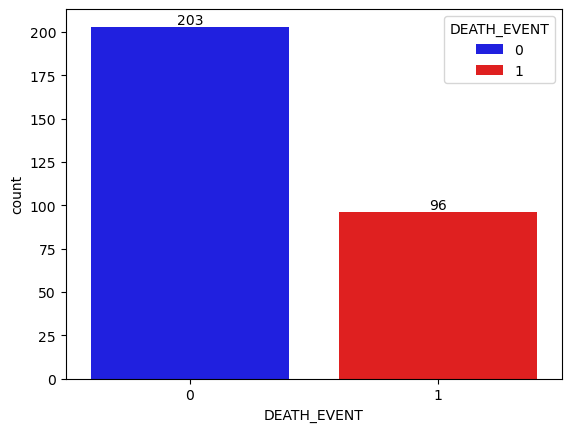

In [6]:
cols = ["#0000FF","#FF0000"]
ax = sns.countplot(x=data_df["DEATH_EVENT"],hue =data_df["DEATH_EVENT"],palette=cols)
for container in ax.containers:ax.bar_label(container)
plt.show()

In [7]:
data_df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,299.0,60.833893,11.894809,40.0,51.0,60.0,70.0,95.0
anaemia,299.0,0.431438,0.496107,0.0,0.0,0.0,1.0,1.0
creatinine_phosphokinase,299.0,581.839465,970.287881,23.0,116.5,250.0,582.0,7861.0
diabetes,299.0,0.418060,0.494067,0.0,0.0,0.0,1.0,1.0
ejection_fraction,299.0,38.083612,11.834841,14.0,30.0,38.0,45.0,80.0
high_blood_pressure,299.0,0.351171,0.478136,0.0,0.0,0.0,1.0,1.0
platelets,299.0,263358.029264,97804.236869,25100.0,212500.0,262000.0,303500.0,850000.0
serum_creatinine,299.0,1.393880,1.034510,0.5,0.9,1.1,1.4,9.4
serum_sodium,299.0,136.625418,4.412477,113.0,134.0,137.0,140.0,148.0
sex,299.0,0.648829,0.478136,0.0,0.0,1.0,1.0,1.0


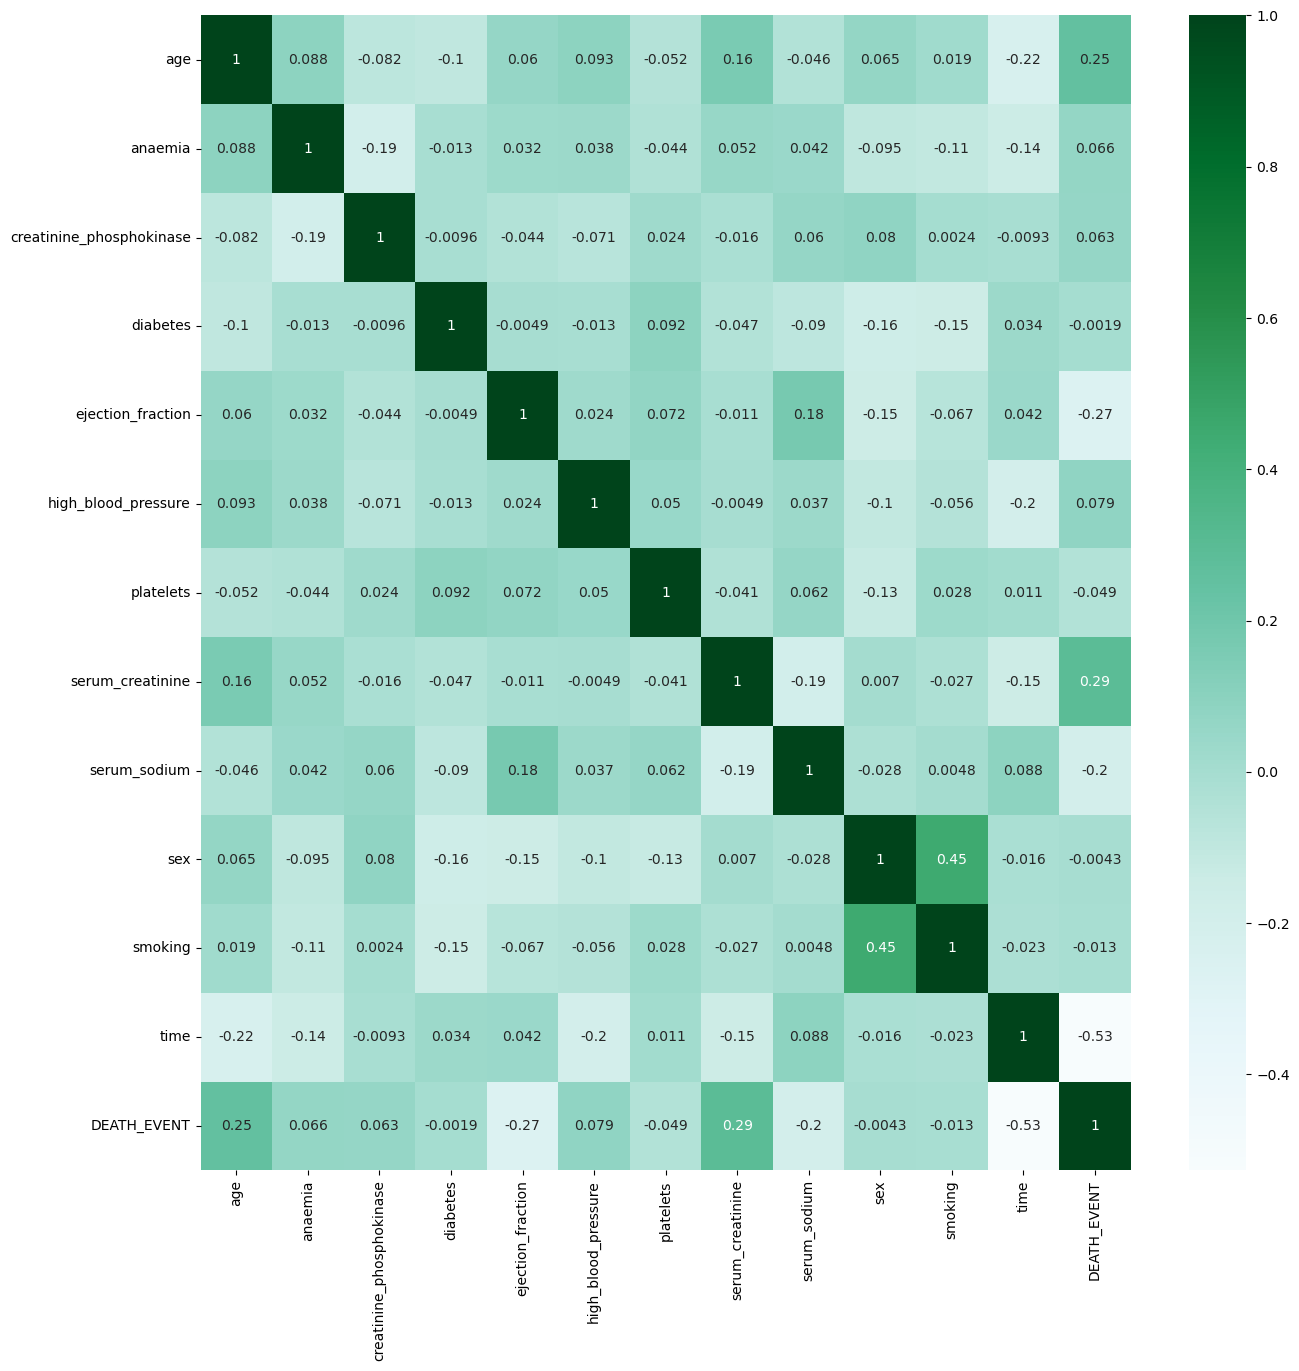

In [8]:
plt.subplots(figsize=(15,15))
sns.heatmap(data_df.corr(), cmap="BuGn",annot=True)
plt.show()

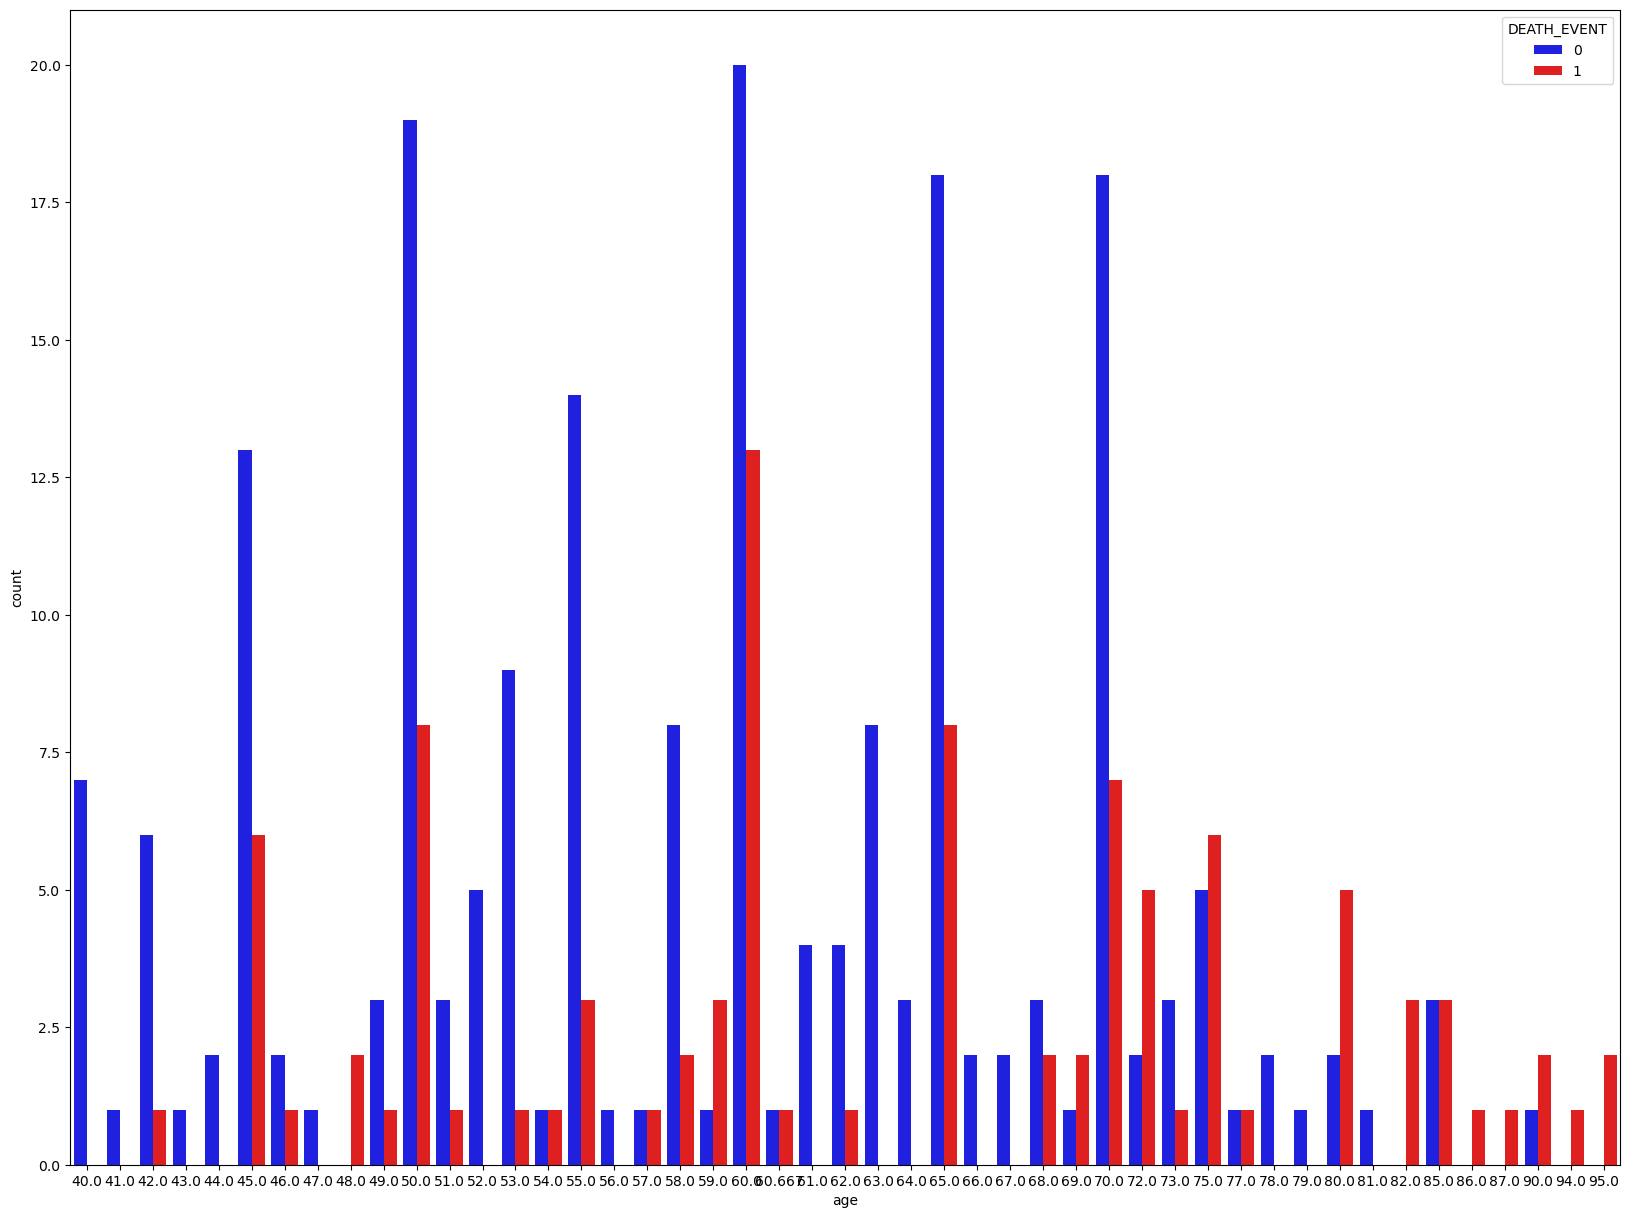

In [9]:
plt.figure(figsize=(20,15))
sns.countplot(data_df,x="age",hue="DEATH_EVENT",palette = cols)
plt.show()

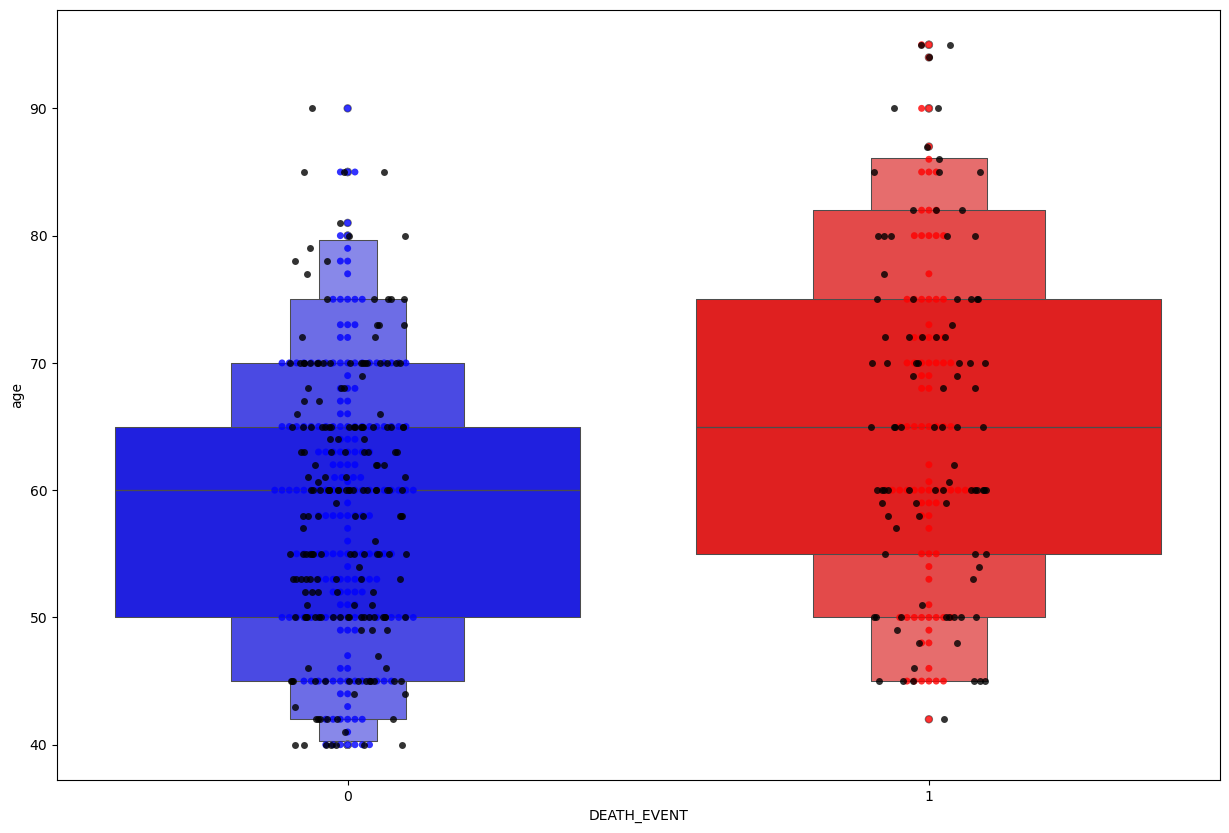

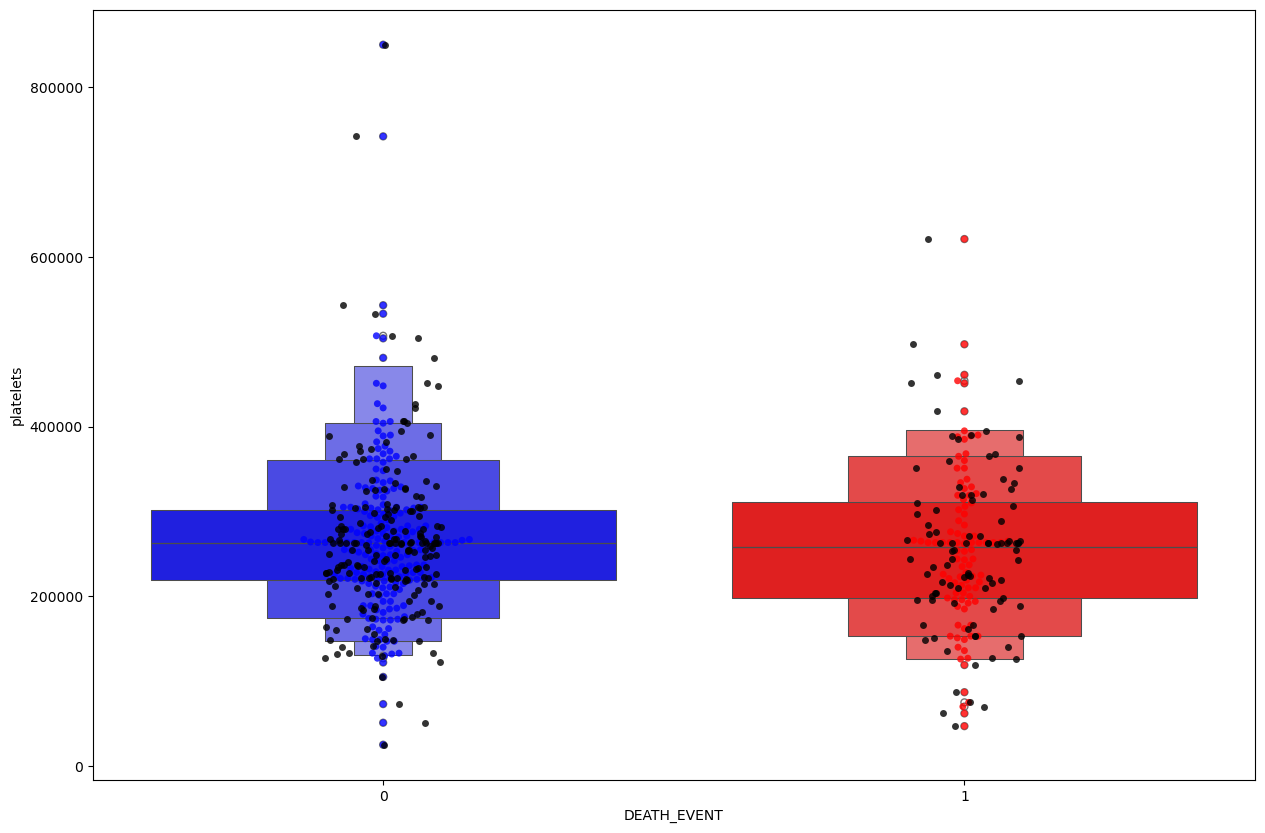

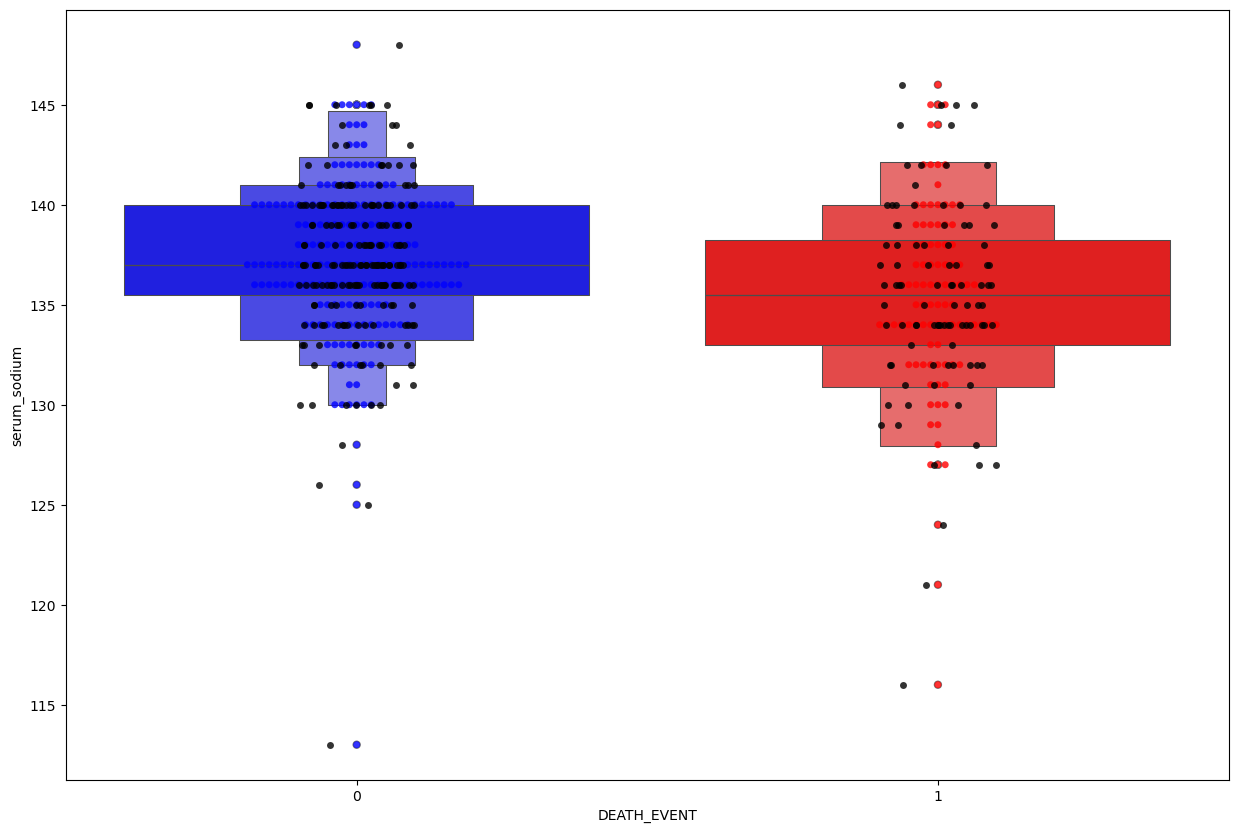

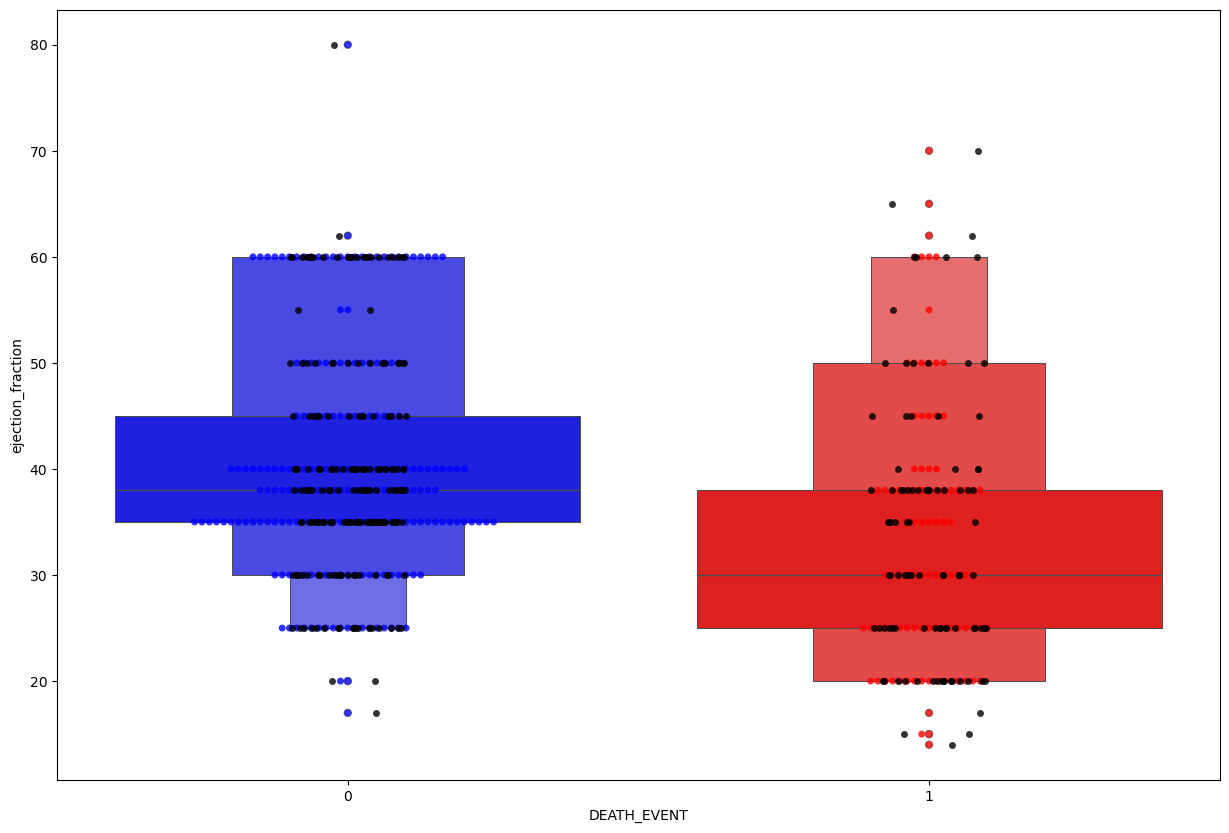

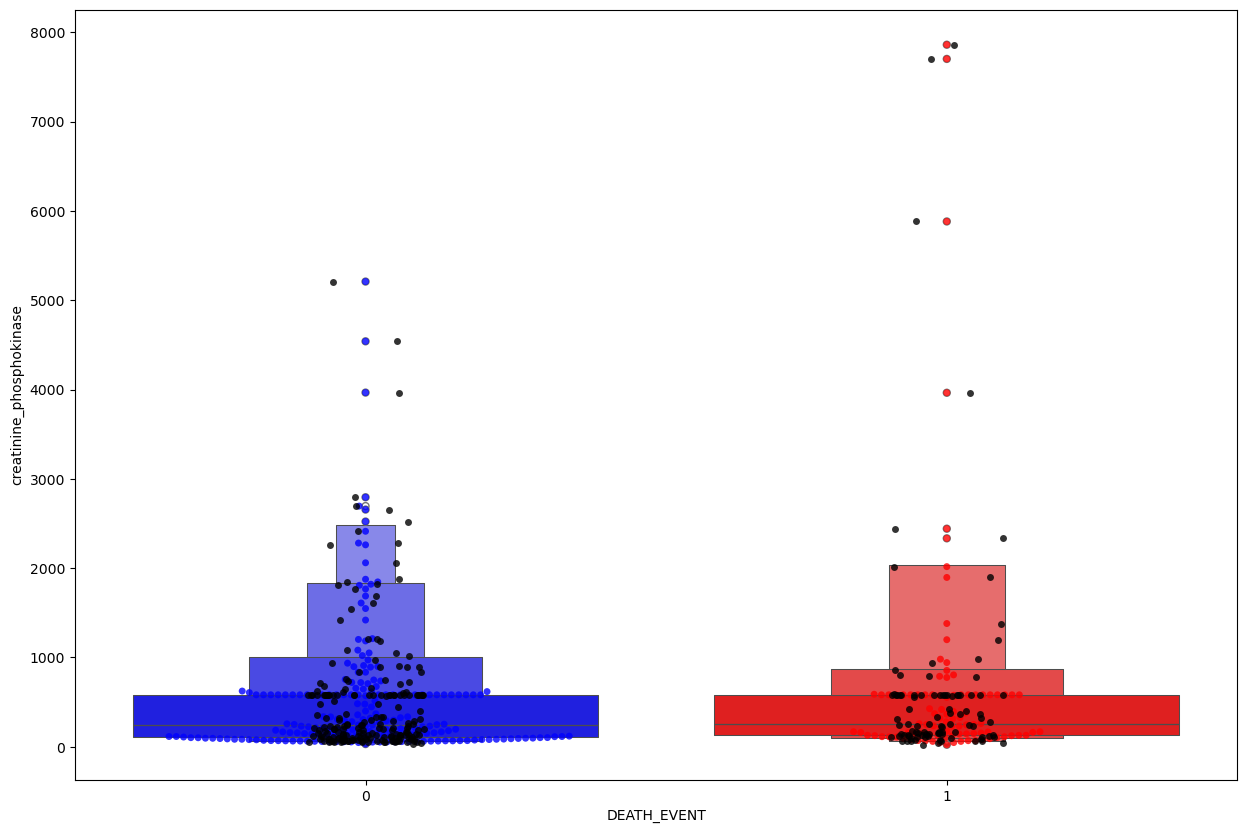

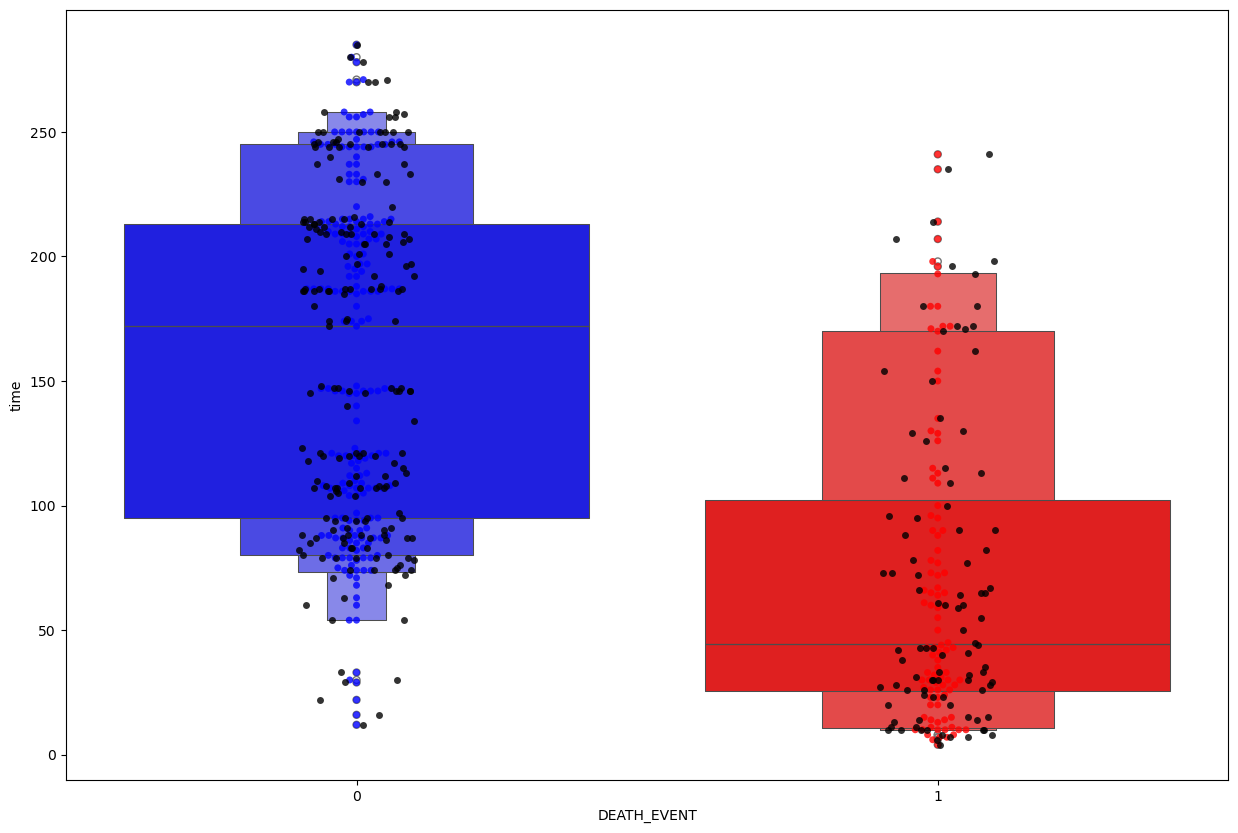

In [10]:
feature = ["age", "platelets", "serum_sodium", "ejection_fraction", "creatinine_phosphokinase", "time"]

for i in feature:
    plt.figure(figsize=(15, 10))
    # 'data' is the DataFrame, 'x' is the category, and 'y' is the column name 'i'
    sns.swarmplot(data=data_df, x="DEATH_EVENT", y=i,hue="DEATH_EVENT",  palette=cols, legend=False, alpha=0.8)
    sns.stripplot(data=data_df, x="DEATH_EVENT", y=i, color="black",  alpha=0.8)
    sns.boxenplot(data=data_df, x="DEATH_EVENT", y=i,hue="DEATH_EVENT", palette=cols,legend=False)
    plt.show()

In [11]:
X = data_df.drop(["DEATH_EVENT"], axis=1)
y = data_df["DEATH_EVENT"]

col_name = list(X.columns)   # fixed typo

from sklearn import preprocessing
s_scaler = preprocessing.StandardScaler()

X_scaled_array = s_scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled_array, columns=col_name)

X_scaled.describe()

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time
count,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,299.000000,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02,2.990000e+02
mean,5.703353e-16,1.009969e-16,0.000000,9.060014e-17,-3.267546e-17,0.000000,7.723291e-17,1.425838e-16,-8.673849e-16,-8.911489e-18,-1.188199e-17,-1.901118e-16
std,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00,1.001676e+00
min,-1.754448e+00,-8.711048e-01,-0.576918,-8.475794e-01,-2.038387e+00,-0.735688,-2.440155e+00,-8.655094e-01,-5.363206e+00,-1.359272e+00,-6.876819e-01,-1.629502e+00
25%,-8.281242e-01,-8.711048e-01,-0.480393,-8.475794e-01,-6.841802e-01,-0.735688,-5.208700e-01,-4.782047e-01,-5.959961e-01,-1.359272e+00,-6.876819e-01,-7.389995e-01
50%,-7.022315e-02,-8.711048e-01,-0.342574,-8.475794e-01,-7.076750e-03,-0.735688,-1.390846e-02,-2.845524e-01,8.503384e-02,7.356882e-01,-6.876819e-01,-1.969543e-01
75%,7.718891e-01,1.147968e+00,0.000166,1.179830e+00,5.853888e-01,1.359272,4.111199e-01,5.926150e-03,7.660638e-01,7.356882e-01,1.454161e+00,9.387595e-01
max,2.877170e+00,1.147968e+00,7.514640,1.179830e+00,3.547716e+00,1.359272,6.008180e+00,7.752020e+00,2.582144e+00,7.356882e-01,1.454161e+00,1.997038e+00


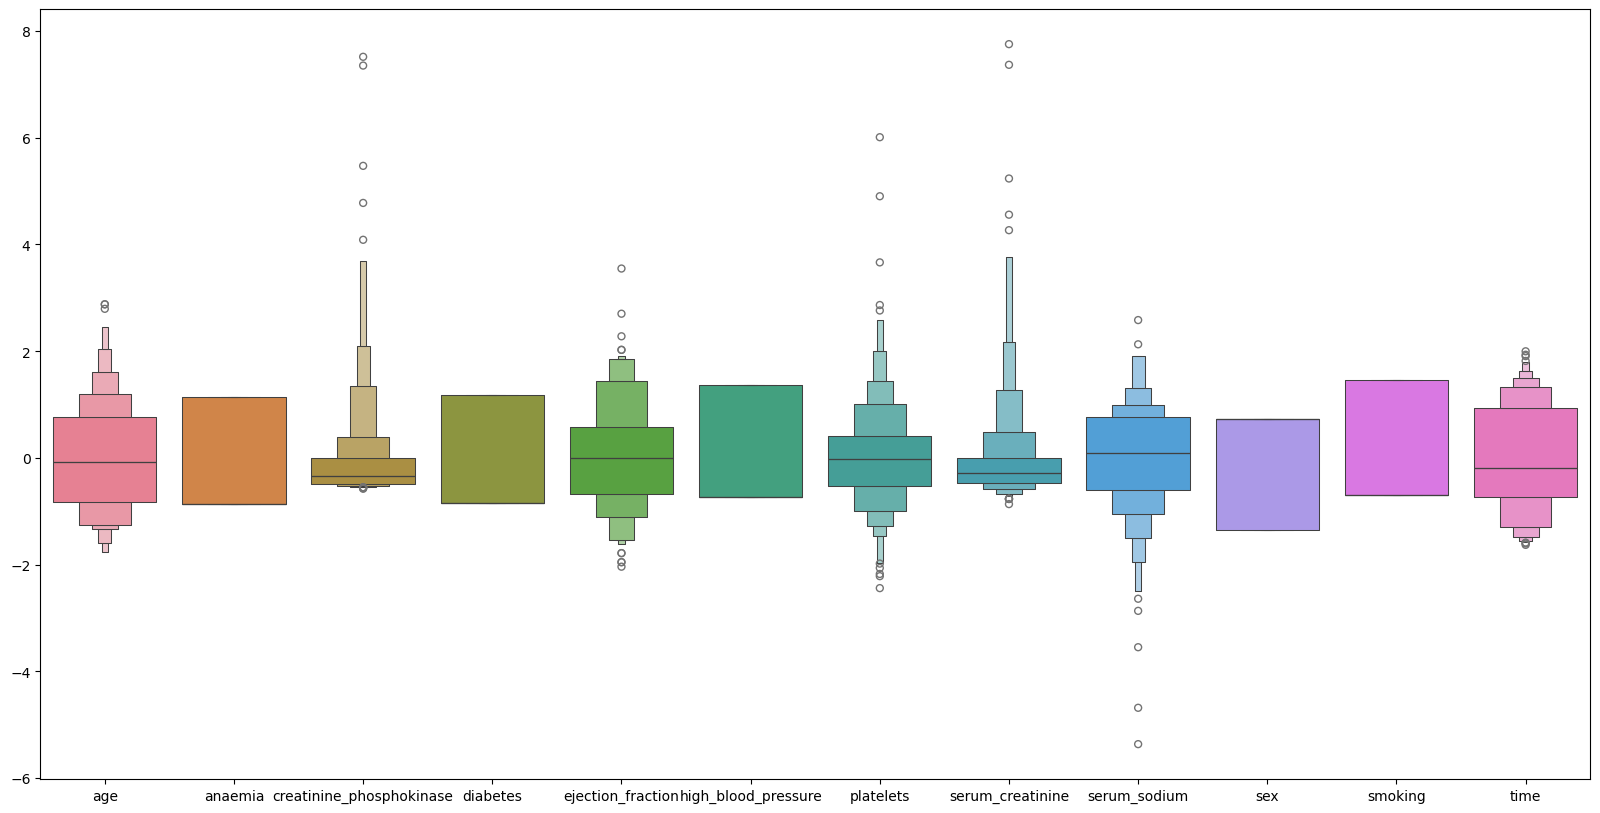

In [12]:
plt.figure(figsize=(20,10))
sns.boxenplot(data=X_scaled)
plt.show()

In [13]:
X_train,X_tests,y_train,y_test=train_test_split(X_scaled,y,test_size=0.4)

In [14]:
model = svm.SVC()
model.fit(X_train,y_train)
y_pred=model.predict(X_tests)


y_pred

In [15]:
y_test


229    0
180    0
113    1
62     0
285    0
      ..
58     1
9      1
43     0
177    0
144    1
Name: DEATH_EVENT, Length: 120, dtype: int64

In [16]:
y_train

63     1
205    0
140    1
172    0
263    0
      ..
197    0
104    0
234    0
158    0
69     1
Name: DEATH_EVENT, Length: 179, dtype: int64

In [17]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83        78
           1       0.72      0.55      0.62        42

    accuracy                           0.77       120
   macro avg       0.75      0.72      0.73       120
weighted avg       0.76      0.77      0.76       120



In [18]:
early_stopping = callbacks.EarlyStopping(
    min_delta = 0.001,patience =20,restore_best_weights = True)
model =Sequential()
model .add(Dense(units =16, kernel_initializer ='uniform',activation ='relu',input_dim=12))
model .add(Dense(units =8, kernel_initializer ='uniform',activation ='relu'))
model.add(Dropout(0.25))
model .add(Dense(units =8, kernel_initializer ='uniform',activation ='relu'))
model.add(Dropout(0.5))
model .add(Dense(units =1, kernel_initializer ='uniform',activation ='sigmoid'))

C:\Users\Alex\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
model.compile(optimizer ='adam',loss ='binary_crossentropy',metrics =['accuracy'])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425 (1.66 KB)

 Trainable params: 425 (1.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
 history=model.fit(X_train,y_train,batch_size=25,epochs=100,callbacks=[early_stopping],validation_split=0.25)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6940 - loss: 0.6927 - val_accuracy: 0.6889 - val_loss: 0.6919
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7015 - loss: 0.6914 - val_accuracy: 0.6889 - val_loss: 0.6906
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7015 - loss: 0.6900 - val_accuracy: 0.6889 - val_loss: 0.6894
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7015 - loss: 0.6884 - val_accuracy: 0.6889 - val_loss: 0.6880
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7015 - loss: 0.6872 - val_accuracy: 0.6889 - val_loss: 0.6865
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7015 - loss: 0.6854 - val_accuracy: 0.6889 - val_loss: 0.6848
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7015 - loss: 0.6833 - val_accuracy: 0.6889 - val_loss: 0.6829
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7015 - loss: 0.6813 - val_accuracy: 0.6889 - val_loss:

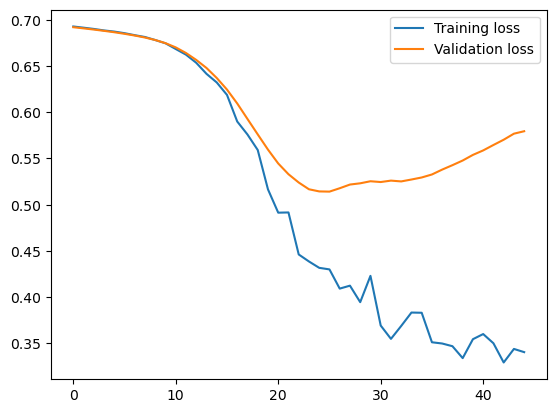

In [22]:
history_df=pd.DataFrame(history.history)

plt.plot(history_df.loc[:,['loss']],label="Training loss")
plt.plot(history_df.loc[:,['val_loss']],label="Validation loss")
plt.legend()
plt.show()

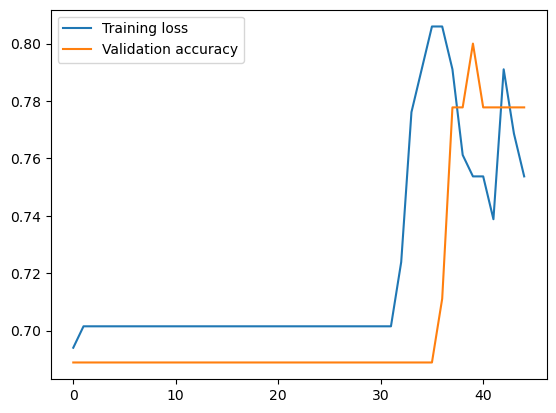

In [23]:
plt.plot(history_df.loc[:,['accuracy']],label="Training loss")
plt.plot(history_df.loc[:,['val_accuracy']],label="Validation accuracy")
plt.legend()
plt.show()

In [24]:
y_pred=model.predict(X_tests)
                     

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [29]:
print(y_pred[10])

[False]


In [36]:
y_pred=(y_pred>0.5)

In [37]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.65      1.00      0.79        78
           1       0.00      0.00      0.00        42

    accuracy                           0.65       120
   macro avg       0.33      0.50      0.39       120
weighted avg       0.42      0.65      0.51       120



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
